In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
# Train set
train_x = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/X_train.csv')
train_y = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/y_train.csv')
train_df = pd.merge(train_x, train_y, on='id')
# Test + validation set
valid_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/X_validation.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/X_test.csv')
# Loadings
loadings_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/loadings.csv')

# Without Normalization

In [100]:
X_unlabeled_df = pd.concat([valid_df, test_df], ignore_index=True)
base_features = ['trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']
loadings = loadings_df.values
train_features = train_df[base_features]
unlabeled_features = X_unlabeled_df[base_features]
train_pca = train_features.values.dot(loadings)
unlabeled_pca = unlabeled_features.values.dot(loadings)

In [101]:
# Train K-NN
train_labels = train_df['faulty'].values
k = 5
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
knn.fit(train_pca, train_labels)

KNeighborsClassifier()

In [102]:
prob_unlabeled = knn.predict_proba(unlabeled_pca)
confidence_faulty = prob_unlabeled[:, 1]

print("First 10 samples unlabeled:")
for i in range(10):
    print(f"Sample {i}, conf. faulty = {confidence_faulty[i]:.3f}")

First 10 samples unlabeled:
Sample 0, conf. faulty = 0.800
Sample 1, conf. faulty = 1.000
Sample 2, conf. faulty = 0.000
Sample 3, conf. faulty = 0.400
Sample 4, conf. faulty = 0.000
Sample 5, conf. faulty = 0.000
Sample 6, conf. faulty = 0.000
Sample 7, conf. faulty = 0.000
Sample 8, conf. faulty = 0.000
Sample 9, conf. faulty = 0.000


In [103]:
threshold = 0.5
unlabeled_pred = (confidence_faulty > threshold).astype(int)
print("First 10 binary prediction (0=healthy, 1=faulty):")
print(unlabeled_pred[:10])

First 10 binary prediction (0=healthy, 1=faulty):
[1 1 0 0 0 0 0 0 0 0]


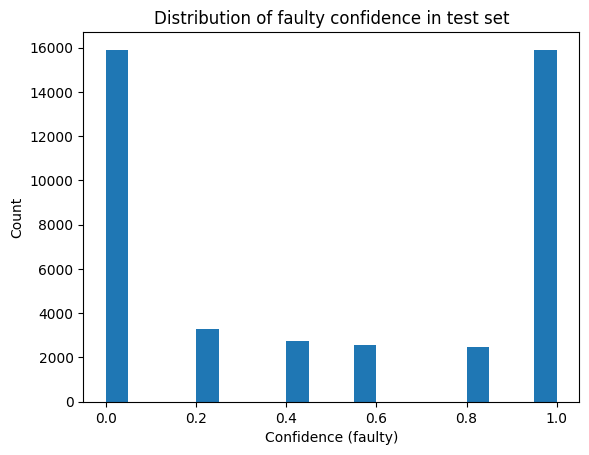

In [104]:
plt.hist(confidence_faulty, bins=20)
plt.xlabel("Confidence (faulty)")
plt.ylabel("Count")
plt.title("Distribution of faulty confidence in test set")
plt.show()

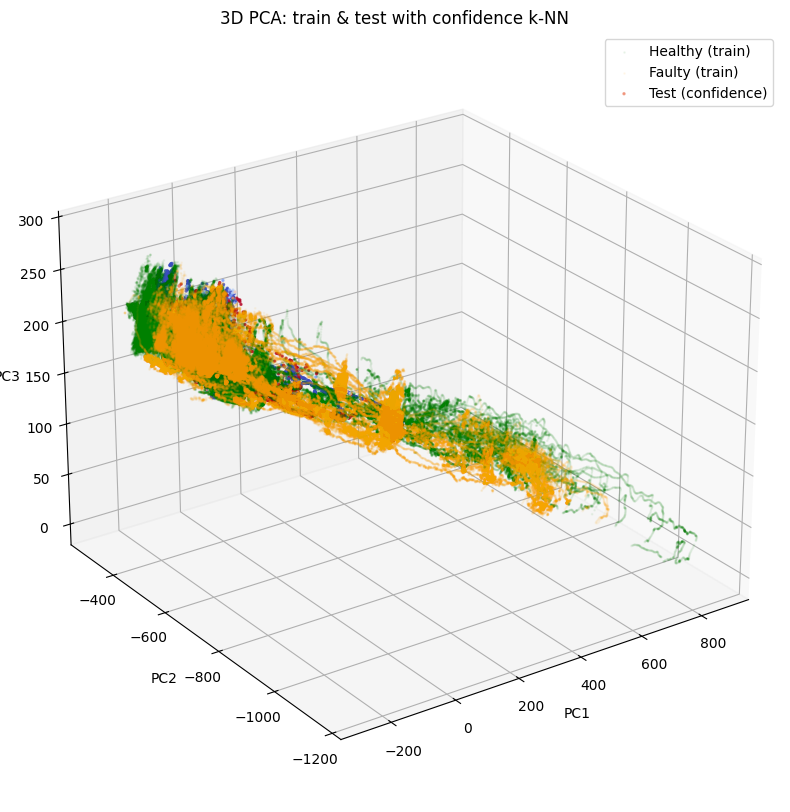

In [107]:
#Plotting training and test with confidence K-NN
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')


healthy_mask = (train_labels == 0)
faulty_mask = (train_labels == 1)


ax.scatter(train_pca[healthy_mask, 0],
           train_pca[healthy_mask, 1],
           train_pca[healthy_mask, 2],
           c='g', alpha=0.05, s=1, label='Healthy (train)')
ax.scatter(train_pca[faulty_mask, 0],
           train_pca[faulty_mask, 1],
           train_pca[faulty_mask, 2],
           c='orange', alpha=0.05, s=1, label='Faulty (train)')


cmap = plt.cm.coolwarm
colors_test = cmap(confidence_faulty)
ax.scatter(unlabeled_pca[:, 0],
           unlabeled_pca[:, 1],
           unlabeled_pca[:, 2],
           c=colors_test, alpha=0.7, s=2, label='Test (confidence)')


ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("3D PCA: train & test with confidence k-NN")
ax.legend(loc='upper right')


ax.view_init(azim=235, elev=25)
plt.show()

In [108]:
unlabeled_out = X_unlabeled_df.copy()
unlabeled_out["faulty_confidence"] = confidence_faulty
threshold = 0.5
unlabeled_out["faulty_pred"] = (confidence_faulty > threshold).astype(int)

print(unlabeled_out.head())

   id  trq_measured    oat    mgt        pa       ias      np     ng  \
0   0          56.5  19.00  553.9  276.7584   73.6875   99.81  91.07   
1   1          86.2   6.75  657.9  657.4536  122.8750  100.03  97.61   
2   2          54.0  21.75  559.6  263.3472   18.1250   99.57  90.62   
3   3          55.4  20.75  566.8  751.0272   84.7500   99.92  91.16   
4   4          51.3  19.50  554.2  755.9040   68.5625   99.99  90.09   

   faulty_confidence  faulty_pred  
0                0.8            1  
1                1.0            1  
2                0.0            0  
3                0.4            0  
4                0.0            0  


# With Normalization

In [95]:
base_features = ['trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']

# Normalization
train_mean = train_df[base_features].mean()
train_std = train_df[base_features].std()

train_features_norm = (train_df[base_features] - train_mean) / train_std
unlabeled_features_norm = (X_unlabeled_df[base_features] - train_mean) / train_std
loadings = loadings_df.values
train_pca = train_features_norm.values.dot(loadings)
unlabeled_pca = unlabeled_features_norm.values.dot(loadings)

# Train K-NN
train_labels = train_df['faulty'].values
k = 5
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
knn.fit(train_pca, train_labels)
prob_unlabeled = knn.predict_proba(unlabeled_pca)
confidence_faulty = prob_unlabeled[:, 1]

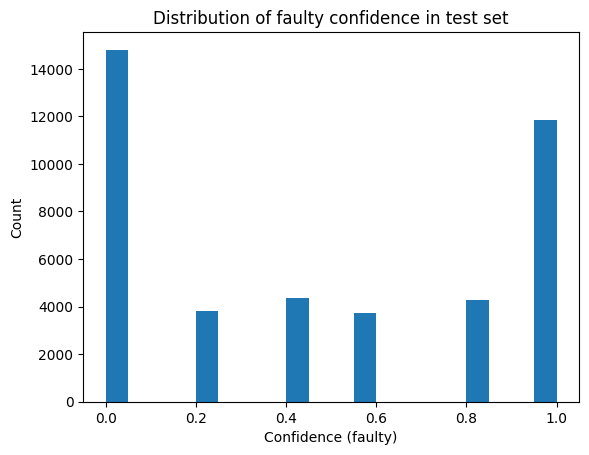

In [98]:
plt.hist(confidence_faulty, bins=20)
plt.xlabel("Confidence (faulty)")
plt.ylabel("Count")
plt.title("Distribution of faulty confidence in test set")
plt.show()

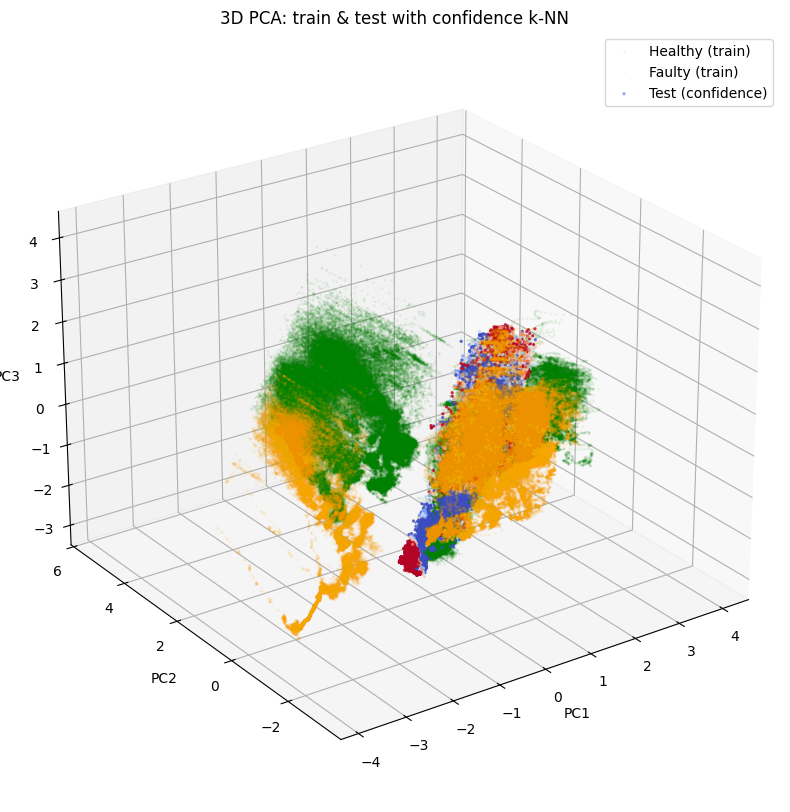

In [85]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

healthy_mask = (train_labels == 0)
faulty_mask = (train_labels == 1)

ax.scatter(train_pca[healthy_mask, 0],
           train_pca[healthy_mask, 1],
           train_pca[healthy_mask, 2],
           c='g', alpha=0.05, s=1, label='Healthy (train)')
ax.scatter(train_pca[faulty_mask, 0],
           train_pca[faulty_mask, 1],
           train_pca[faulty_mask, 2],
           c='orange', alpha=0.05, s=1, label='Faulty (train)')

cmap = plt.cm.coolwarm
colors_test = cmap(confidence_faulty)
ax.scatter(unlabeled_pca[:, 0],
           unlabeled_pca[:, 1],
           unlabeled_pca[:, 2],
           c=colors_test, alpha=0.7, s=2, label='Test (confidence)')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title("3D PCA: train & test with confidence k-NN")
ax.legend(loc='upper right')

ax.view_init(azim=235, elev=25)
plt.show()

In [96]:
unlabeled_out = X_unlabeled_df.copy()
unlabeled_out["faulty_confidence"] = confidence_faulty
threshold = 0.5
unlabeled_out["faulty_pred"] = (confidence_faulty > threshold).astype(int)

print(unlabeled_out.head())

   id  trq_measured    oat    mgt        pa       ias      np     ng  \
0   0          56.5  19.00  553.9  276.7584   73.6875   99.81  91.07   
1   1          86.2   6.75  657.9  657.4536  122.8750  100.03  97.61   
2   2          54.0  21.75  559.6  263.3472   18.1250   99.57  90.62   
3   3          55.4  20.75  566.8  751.0272   84.7500   99.92  91.16   
4   4          51.3  19.50  554.2  755.9040   68.5625   99.99  90.09   

   faulty_confidence  faulty_pred  
0                0.2            0  
1                0.0            0  
2                0.2            0  
3                1.0            1  
4                1.0            1  
